<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab9_Build_a_Mini_Autograd_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 9 · Build a Mini Autograd Engine

> **Deep Learning foundations — Lab 9 (Part II).** A deeper companion to **Lab 4 (Back-propagation)**. Run top to bottom
> (Runtime → Run all), read the plain-English notes, and finish the **Your turn 🧪** cell. Built from scratch with
> NumPy so nothing is hidden.

### In plain English
Lab 4 hand-derived back-prop for one fixed network. But real frameworks (PyTorch, TensorFlow) don't hand-derive
anything — they build a **graph of tiny operations** and replay the chain rule backwards through *any* graph
automatically. That's **reverse-mode autodiff**. In ~40 lines we build our own, verify it against numerical
gradients, then train a neural net with it.

In [1]:
import math, random
import numpy as np, matplotlib.pyplot as plt

class Value:
    """A scalar that remembers how it was computed, so it can back-propagate."""
    def __init__(self, data, _children=(), _op=''):
        self.data=data; self.grad=0.0
        self._backward=lambda: None
        self._prev=set(_children); self._op=_op
    def __add__(self,o):
        o=o if isinstance(o,Value) else Value(o); out=Value(self.data+o.data,(self,o),'+')
        def _b(): self.grad+=out.grad; o.grad+=out.grad
        out._backward=_b; return out
    def __mul__(self,o):
        o=o if isinstance(o,Value) else Value(o); out=Value(self.data*o.data,(self,o),'*')
        def _b(): self.grad+=o.data*out.grad; o.grad+=self.data*out.grad
        out._backward=_b; return out
    def __pow__(self,o):
        assert isinstance(o,(int,float)); out=Value(self.data**o,(self,),f'**{o}')
        def _b(): self.grad+=o*self.data**(o-1)*out.grad
        out._backward=_b; return out
    def tanh(self):
        t=math.tanh(self.data); out=Value(t,(self,),'tanh')
        def _b(): self.grad+=(1-t*t)*out.grad
        out._backward=_b; return out
    def relu(self):
        out=Value(max(0.0,self.data),(self,),'relu')
        def _b(): self.grad+=(out.data>0)*out.grad
        out._backward=_b; return out
    def __neg__(self): return self*-1
    def __radd__(self,o): return self+o
    def __sub__(self,o): return self+(-o)
    def __rsub__(self,o): return o+(-self)
    def __rmul__(self,o): return self*o
    def __truediv__(self,o): return self*o**-1
    def backward(self):
        topo=[]; seen=set()
        def build(v):
            if v not in seen:
                seen.add(v)
                for c in v._prev: build(c)
                topo.append(v)
        build(self); self.grad=1.0
        for v in reversed(topo): v._backward()
    def __repr__(self): return f"Value({self.data:.4f}, grad={self.grad:.4f})"

print("engine defined.")

engine defined.


## 1 · Gradient check against finite differences

In [2]:
# a rich expression mixing +, *, **, and / (a rational-polynomial)
def f(a,b): return a*b + b**3 - a/b
a=Value(-2.0); b=Value(3.0)
out=a*b + b**3 - a/b            # build the graph
out.backward()                  # one backward sweep fills every .grad
eps=1e-6
ga=(f(-2+eps,3)-f(-2-eps,3))/(2*eps)
gb=(f(-2,3+eps)-f(-2,3-eps))/(2*eps)
print(f"∂out/∂a : autograd {a.grad:+.5f}   numeric {ga:+.5f}   (= b - 1/b)")
print(f"∂out/∂b : autograd {b.grad:+.5f}   numeric {gb:+.5f}   (= a + 3b² + a/b²)")
print("match:", abs(a.grad-ga)<1e-4 and abs(b.grad-gb)<1e-4)

# and a stand-alone check of the tanh gradient (1 - tanh²)
t=Value(0.7); y=t.tanh(); y.backward()
print()
print("tanh gradient at 0.7:", round(t.grad,5), " expected", round(1-math.tanh(0.7)**2,5))

∂out/∂a : autograd +2.66667   numeric +2.66667   (= b - 1/b)
∂out/∂b : autograd +24.77778   numeric +24.77778   (= a + 3b² + a/b²)
match: True

tanh gradient at 0.7: 0.63474  expected 0.63474


## 2 · A neural net built on the engine

In [3]:
class Neuron:
    def __init__(self,nin,rng,nonlin=True):
        self.w=[Value(rng.uniform(-1,1)) for _ in range(nin)]; self.b=Value(0.0); self.nonlin=nonlin
    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        return act.tanh() if self.nonlin else act
    def parameters(self): return self.w+[self.b]
class Layer:
    def __init__(self,nin,nout,rng,**kw): self.neurons=[Neuron(nin,rng,**kw) for _ in range(nout)]
    def __call__(self,x):
        o=[n(x) for n in self.neurons]; return o[0] if len(o)==1 else o
    def parameters(self): return [p for n in self.neurons for p in n.parameters()]
class MLP:
    def __init__(self,nin,nouts,rng):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1],rng,nonlin=i!=len(nouts)-1) for i in range(len(nouts))]
    def __call__(self,x):
        for l in self.layers: x=l(x)
        return x
    def parameters(self): return [p for l in self.layers for p in l.parameters()]

rng=random.Random(1)
model=MLP(2,[8,1],rng)   # one hidden layer of 8 tanh units is plenty for XOR
print("parameters:", len(model.parameters()))

parameters: 33


## 3 · Train it on XOR (targets ±1)

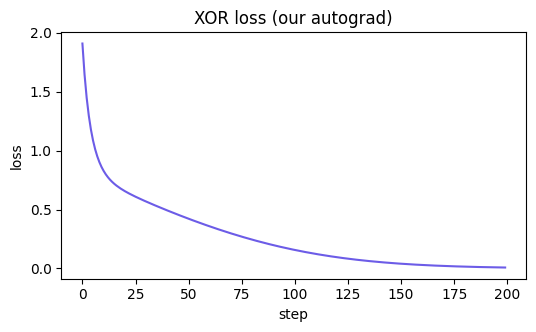

final loss: 0.0083
  [0, 0] -> -0.95  (target -1)  ✓
  [0, 1] -> +0.90  (target +1)  ✓
  [1, 0] -> +0.92  (target +1)  ✓
  [1, 1] -> -0.88  (target -1)  ✓


In [4]:
X=[[0,0],[0,1],[1,0],[1,1]]; Y=[-1.0,1.0,1.0,-1.0]
losses=[]
for step in range(200):
    preds=[model(x) for x in X]
    loss=sum((p-y)**2 for p,y in zip(preds,Y))*(1.0/len(X))   # MEAN squared error, built from Values
    for p in model.parameters(): p.grad=0.0                   # reset grads
    loss.backward()                                           # one backward sweep fills every grad
    for p in model.parameters(): p.data-=0.05*p.grad          # gradient-descent step
    losses.append(loss.data)

plt.figure(figsize=(6,3.2)); plt.plot(losses,color="#6C5CE7"); plt.title("XOR loss (our autograd)"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()
print("final loss:", round(losses[-1],4))
for x,y in zip(X,Y):
    pred=model(x).data
    print(f"  {x} -> {pred:+.2f}  (target {y:+.0f})  {'✓' if (pred>0)==(y>0) else '✗'}")

## Your turn 🧪
1. Add an `exp` operation to `Value` (its gradient is `exp(x)`), then build a softmax out of your engine.
2. Swap the hidden activation from `tanh` to `relu` in `Neuron`. Does XOR still train?
3. This engine is scalar (slow). Explain in one sentence why PyTorch stores whole **tensors** at each node instead.

In [5]:
# Your turn: add exp and test its gradient
def _exp(self):
    import math; e=math.exp(self.data); out=Value(e,(self,),'exp')
    def _b(): self.grad+=e*out.grad
    out._backward=_b; return out
Value.exp=_exp
v=Value(1.0); (v.exp()).backward()
print("d/dx exp(x) at x=1:", round(v.grad,5), "≈ e =", round(math.e,5))

d/dx exp(x) at x=1: 2.71828 ≈ e = 2.71828
